In [22]:
!pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable


In [23]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Load the dataset (update path if necessary)
file_path = "data/nifty50/close/Monday/close_Monday_log_return.csv"  # Change this path if needed
df = pd.read_csv(file_path)

# Define input (09:15 - 14:25) and output (14:25 - 15:25) columns
input_columns = df.columns[1:df.columns.get_loc("14:25:00")]
output_columns = ["14:25:00", "14:30:00", "14:35:00", "14:40:00", "14:45:00", 
                  "14:50:00", "14:55:00", "15:00:00", "15:05:00", "15:10:00", 
                  "15:15:00", "15:20:00", "15:25:00"]

# Extract input and output data
X = df[input_columns].values  # 63 time steps
Y = df[output_columns].values  # 12 time steps

# Normalize data
X_mean, X_std = X.mean(), X.std()
Y_mean, Y_std = Y.mean(), Y.std()

X = (X - X_mean) / X_std  # Normalize input
Y = (Y - Y_mean) / Y_std  # Normalize output

# Convert to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

# Split into train and test sets
train_size = int(0.8 * len(X))
X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]
Y_train, Y_test = Y_tensor[:train_size], Y_tensor[train_size:]

# Create DataLoader for batching
batch_size = 32
train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [24]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    """
    Standard sinusoidal positional encoding module.
    This helps the Transformer attend to the order of time steps.
    """
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)  # (max_len, d_model)
        
        # Position indices (0, 1, 2, ...)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # Exponential term for sine/cosine frequencies
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                             (-math.log(10000.0) / d_model))
        
        # Apply sine to even indices and cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Add batch dimension
        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        
        # Register as buffer so it’s not trained
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x shape: (batch_size, seq_len, d_model)
        Returns the input plus positional encoding of the same shape.
        """
        seq_len = x.size(1)
        # Add positional encoding up to seq_len
        x = x + self.pe[:, :seq_len, :]
        return x


class TransformerTimeSeries(nn.Module):
    def __init__(self, input_dim, output_dim,
                 d_model=64, num_heads=4, num_layers=3, dropout=0.35,
                 max_len=5000):
        """
        Args:
            input_dim:  number of time steps in the input sequence (e.g., 63)
            output_dim: number of time steps to predict (e.g., 12)
            d_model:    hidden dimension inside the Transformer
            num_heads:  number of attention heads
            num_layers: number of Transformer encoder layers
            dropout:    dropout probability
            max_len:    maximum sequence length for positional encoding
        """
        super(TransformerTimeSeries, self).__init__()
        
        # We embed each time-step scalar into a d_model-dimensional vector
        self.embedding = nn.Linear(1, d_model)
        
        # Positional Encoding
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=num_heads, 
            dropout=dropout, 
            batch_first=True  # <--- crucial to keep shape (B, S, E)
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_layers
        )
        
        # Final linear layer to output predictions
        self.fc_out = nn.Linear(d_model, output_dim)

    def forward(self, x):
        """
        x shape: (batch_size, seq_len)
        Returns:
            predictions of shape (batch_size, output_dim)
        """
        # 1) Expand from (batch_size, seq_len) to (batch_size, seq_len, 1)
        x = x.unsqueeze(-1)
        
        # 2) Embed: (batch_size, seq_len, d_model)
        x = self.embedding(x)
        
        # 3) Add positional encoding
        x = self.pos_encoder(x)
        
        # 4) Pass through the Transformer Encoder
        #    Output shape: (batch_size, seq_len, d_model)
        x = self.transformer_encoder(x)
        
        # 5) Pool (mean) over the time dimension
        x = x.mean(dim=1)  # shape: (batch_size, d_model)
        
        # 6) Final linear layer for multi-step output
        x = self.fc_out(x)  # shape: (batch_size, output_dim)
        return x

In [25]:
import torch
import torch.optim as optim
import torch.nn as nn

# Set device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assume you have X_train, Y_train, and a DataLoader called train_loader
# that yields (X_batch, Y_batch) of shapes:
#   X_batch: (batch_size, seq_len)
#   Y_batch: (batch_size, output_dim)

# Hyperparameters
input_dim = X_train.shape[1]   # e.g., 63 time steps
output_dim = Y_train.shape[1]  # e.g., 12 time steps
d_model = 64
num_heads = 4
num_layers = 3
dropout = 0.35
learning_rate = 5e-5
num_epochs = 1000

# Initialize model
model = TransformerTimeSeries(
    input_dim=input_dim,
    output_dim=output_dim,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout,
    max_len=1000
).to(device)

# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    
    for X_batch, Y_batch in train_loader:
        # Move data to GPU if available
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        # Forward pass
        predictions = model(X_batch)
        
        # Compute loss
        loss = criterion(predictions, Y_batch)
        
        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Average training loss for the epoch
    avg_train_loss = total_loss / len(train_loader)
    
    # Print every 10 epochs (adjust to your preference)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {avg_train_loss:.6f}")

# Optionally, if you have a validation set:
# model.eval()
# val_loss = 0.0
# with torch.no_grad():
#     for X_val, Y_val in val_loader:
#         X_val, Y_val = X_val.to(device), Y_val.to(device)
#         val_preds = model(X_val)
#         val_loss += criterion(val_preds, Y_val).item()
# val_loss /= len(val_loader)
# print(f"Validation Loss: {val_loss:.6f}")

Epoch [10/1000], Train Loss: 0.470362
Epoch [20/1000], Train Loss: 0.413334
Epoch [30/1000], Train Loss: 0.345293
Epoch [40/1000], Train Loss: 0.305731
Epoch [50/1000], Train Loss: 0.270480
Epoch [60/1000], Train Loss: 0.254364
Epoch [70/1000], Train Loss: 0.239366
Epoch [80/1000], Train Loss: 0.235354
Epoch [90/1000], Train Loss: 0.218180
Epoch [100/1000], Train Loss: 0.217518
Epoch [110/1000], Train Loss: 0.197201
Epoch [120/1000], Train Loss: 0.189963
Epoch [130/1000], Train Loss: 0.193256
Epoch [140/1000], Train Loss: 0.175313
Epoch [150/1000], Train Loss: 0.170530
Epoch [160/1000], Train Loss: 0.170177
Epoch [170/1000], Train Loss: 0.162868
Epoch [180/1000], Train Loss: 0.151653
Epoch [190/1000], Train Loss: 0.150851
Epoch [200/1000], Train Loss: 0.153142
Epoch [210/1000], Train Loss: 0.146153
Epoch [220/1000], Train Loss: 0.140732
Epoch [230/1000], Train Loss: 0.136112
Epoch [240/1000], Train Loss: 0.142583
Epoch [250/1000], Train Loss: 0.131182
Epoch [260/1000], Train Loss: 0.12

In [26]:
# Evaluate on test set
model.eval()
with torch.no_grad():
    Y_pred = model(X_test.to(device))

# Convert back to original scale
Y_pred = Y_pred.cpu().numpy() * Y_std + Y_mean
Y_test = Y_test.numpy() * Y_std + Y_mean

# Convert to DataFrame and show results
predictions_df = pd.DataFrame(Y_pred, columns=output_columns)
predictions_df.insert(0, "Actual_Example", Y_test[:, 0])  # Include actual values for reference

print(predictions_df.head(10))  # Print first 10 predictions vs actual

   Actual_Example  14:25:00  14:30:00  14:35:00  14:40:00  14:45:00  14:50:00  \
0        0.000416 -0.002064 -0.001128 -0.002307 -0.001877 -0.002843 -0.002849   
1       -0.008374 -0.007314 -0.006397 -0.007046 -0.006988 -0.007361 -0.007311   
2        0.001851  0.003377  0.003389  0.002961  0.003296  0.003039  0.002776   
3       -0.012282 -0.018256 -0.018213 -0.018384 -0.017745 -0.017180 -0.017061   
4        0.005885  0.005404  0.005689  0.005281  0.006928  0.007098  0.007384   
5        0.001695  0.003457  0.003189  0.002881  0.002863  0.001894  0.000935   
6        0.002226  0.001893  0.002350  0.002048  0.002849  0.003417  0.002864   
7        0.003612  0.004129  0.004764  0.004860  0.004635  0.005044  0.005001   
8       -0.001820 -0.001489 -0.001269 -0.001183 -0.000774 -0.000493 -0.000885   
9       -0.019482 -0.012846 -0.015580 -0.015266 -0.015853 -0.019210 -0.018638   

   14:55:00  15:00:00  15:05:00  15:10:00  15:15:00  15:20:00  15:25:00  
0 -0.001514 -0.001292 -0.001713 -0

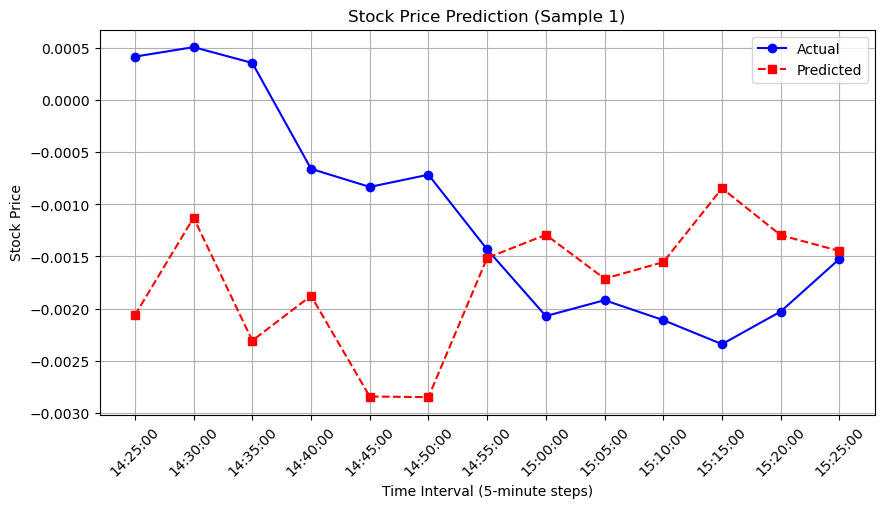

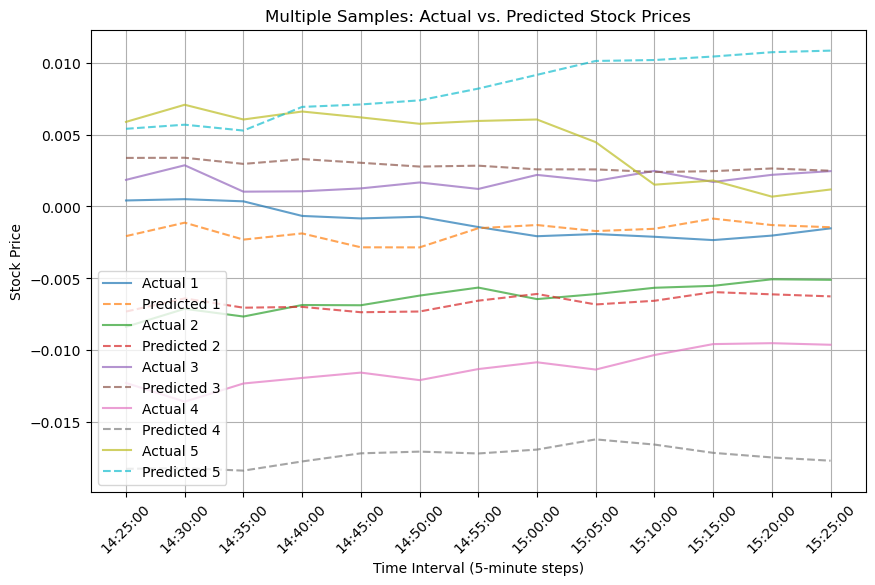

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming Y_pred (predicted values) and Y_test (actual values) are available
# Replace these with actual variable names if needed

# Select a test sample for individual plotting
sample_index = 0  # Choose which test sample to visualize
actual = Y_test[sample_index]
predicted = Y_pred[sample_index]

# --- Graph 1: Single Sample Prediction vs Actual ---
plt.figure(figsize=(10, 5))
plt.plot(output_columns, actual, label="Actual", marker="o", linestyle="-", color="blue")
plt.plot(output_columns, predicted, label="Predicted", marker="s", linestyle="--", color="red")
plt.title(f"Stock Price Prediction (Sample {sample_index+1})")
plt.xlabel("Time Interval (5-minute steps)")
plt.ylabel("Stock Price")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# --- Graph 2: Multiple Samples Comparison ---
num_samples = min(5, len(Y_test))  # Choose up to 5 samples
plt.figure(figsize=(10, 6))

for i in range(num_samples):
    plt.plot(output_columns, Y_test[i], label=f"Actual {i+1}", linestyle="-", alpha=0.7)
    plt.plot(output_columns, Y_pred[i], label=f"Predicted {i+1}", linestyle="--", alpha=0.7)

plt.title("Multiple Samples: Actual vs. Predicted Stock Prices")
plt.xlabel("Time Interval (5-minute steps)")
plt.ylabel("Stock Price")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

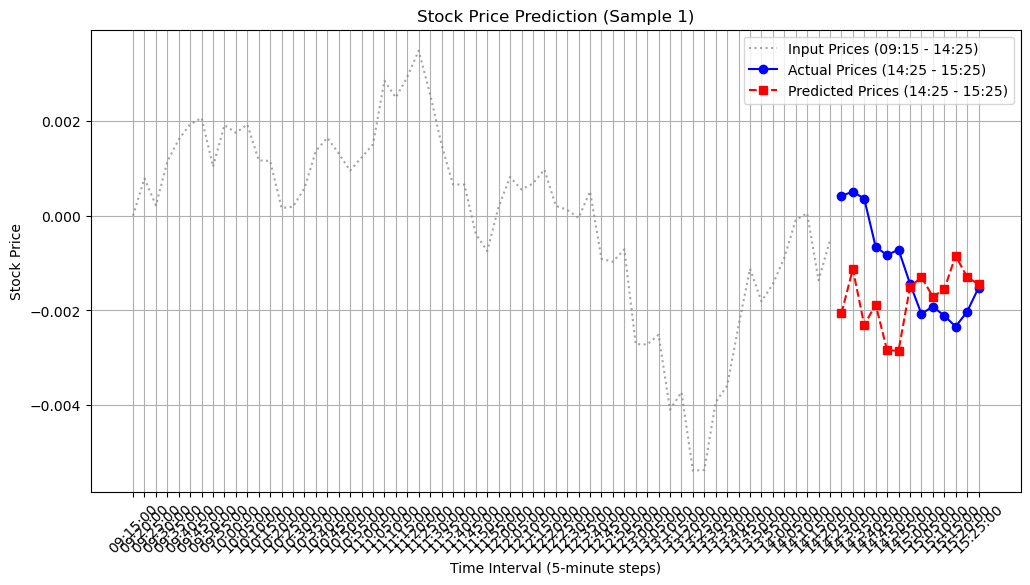

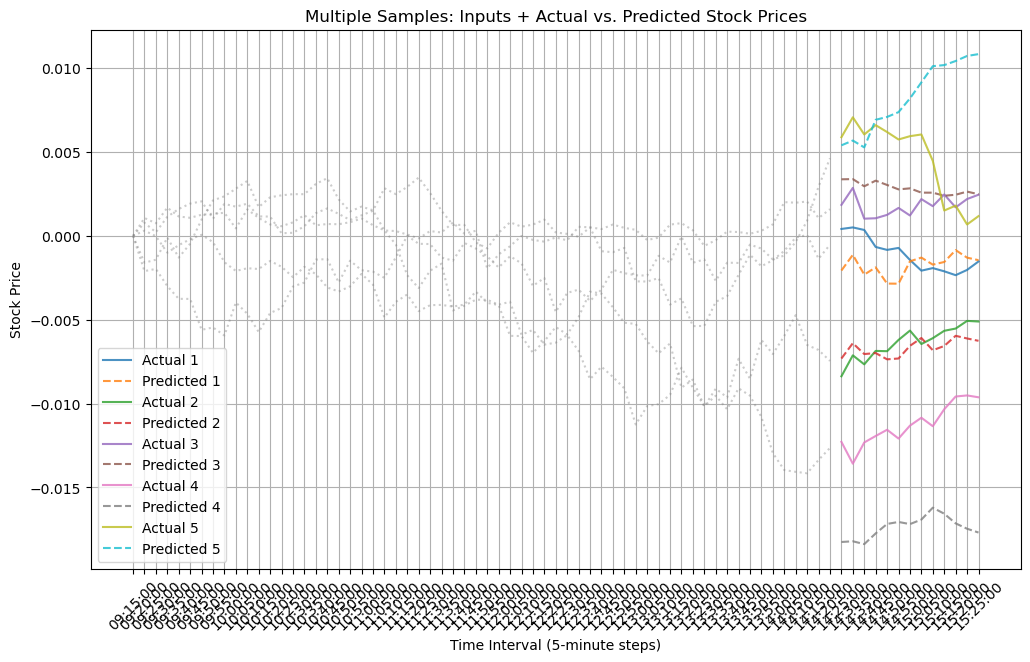

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming X_test (input values), Y_test (actual values), and Y_pred (predicted values) are available
# Replace these with actual variable names if needed

# Select a test sample for individual plotting
sample_index = 0  # Choose which test sample to visualize
input_values = X_test[sample_index] * X_std + X_mean  # Convert input back to original scale
actual = Y_test[sample_index]
predicted = Y_pred[sample_index]

# Define time ranges for input and output
input_time = input_columns  # 09:15 - 14:25 (63 time steps)
output_time = output_columns  # 14:25 - 15:25 (12 time steps)

# --- Graph 1: Single Sample - Input + Actual vs. Predicted ---
plt.figure(figsize=(12, 6))

# Plot input prices
plt.plot(input_time, input_values, label="Input Prices (09:15 - 14:25)", linestyle=":", color="gray", alpha=0.7)

# Plot actual and predicted output prices
plt.plot(output_time, actual, label="Actual Prices (14:25 - 15:25)", marker="o", linestyle="-", color="blue")
plt.plot(output_time, predicted, label="Predicted Prices (14:25 - 15:25)", marker="s", linestyle="--", color="red")

plt.title(f"Stock Price Prediction (Sample {sample_index+1})")
plt.xlabel("Time Interval (5-minute steps)")
plt.ylabel("Stock Price")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# --- Graph 2: Multiple Samples Comparison (Input + Output) ---
num_samples = min(5, len(Y_test))  # Choose up to 5 samples
plt.figure(figsize=(12, 7))

for i in range(num_samples):
    input_values = X_test[i] * X_std + X_mean  # Convert back to original scale
    plt.plot(input_time, input_values, linestyle=":", alpha=0.4, color="gray")  # Plot input values
    
    plt.plot(output_time, Y_test[i], label=f"Actual {i+1}", linestyle="-", alpha=0.8)
    plt.plot(output_time, Y_pred[i], label=f"Predicted {i+1}", linestyle="--", alpha=0.8)

plt.title("Multiple Samples: Inputs + Actual vs. Predicted Stock Prices")
plt.xlabel("Time Interval (5-minute steps)")
plt.ylabel("Stock Price")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()